# 实验：RQ3 手工粗粒化案例还原

这个 notebook 单独还原 `docs/研究框架.md` 里那套 6 节点手工布尔系统，并把三块核心证据放在同一条叙事线上：微观拓扑图、最优粗粒化下的宏微观对照图，以及附录里的代表性非最优粗粒化对照图。


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'exp' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from IPython import get_ipython
    from IPython.display import HTML, SVG, display
except Exception:
    HTML = None
    SVG = None
    get_ipython = None

    def display(value):
        print(value)

DISPLAY_INLINE = bool(get_ipython is not None and get_ipython() is not None and HTML is not None and SVG is not None)

from utils import run_manual_case_analysis


## Experiment Config

这里只保留 notebook 层真正需要改的开关：是否强制重算缓存，以及是否把稳定图资产重新导出到 `fig/`。


In [2]:
experiment_config = {
    "refresh_cache": False,
    "export_figures": True,
}


## Plot Config

图相关参数也单独放一格，方便以后只调展示路径而不碰实验逻辑。


In [3]:
plot_config = {
    "show_inline": DISPLAY_INLINE,
    "figure_dir": Path("fig/rq3_boolean_causal_emergence"),
    "cache_dir": Path("exp/cache/rq3_manual_case"),
    "results_dir": Path("results/rq3_manual_case"),
}


## Run Or Load Results

这一格只做一次薄调用：support 模块负责手工系统 TPM、OR 粗粒化搜索、图渲染和缓存读写。


In [4]:
MANUAL_CASE_ANALYSIS = run_manual_case_analysis(
    refresh_cache=bool(experiment_config["refresh_cache"]),
    export_figures=bool(experiment_config["export_figures"]),
)

MANUAL_CASE_RESULTS = MANUAL_CASE_ANALYSIS["MANUAL_CASE_RESULTS"]
topology_svg = MANUAL_CASE_ANALYSIS["topology_svg"]
optimal_comparison_svg = MANUAL_CASE_ANALYSIS["optimal_comparison_svg"]
nonoptimal_comparison_svg = MANUAL_CASE_ANALYSIS["nonoptimal_comparison_svg"]
MICRO_MECHANISM_HYPEREDGES = MANUAL_CASE_ANALYSIS["micro_mechanism_hyperedges"]
metrics_html = MANUAL_CASE_ANALYSIS["metrics_html"]
manual_case_cache_path = MANUAL_CASE_ANALYSIS["manual_case_cache_path"]


## 关键指标解读

最重要的对比有三组：自然分组的最优 OR 粗粒化、附录里专门挑出来的代表性非最优分组，以及当前 support 模块下对全部 `90` 个三块 OR 分区的均值。这里把均值明确写成“OR partition mean”，避免把它和更宽的随机映射基线混在一起。


In [5]:
if plot_config["show_inline"]:
    display(HTML(metrics_html))


Case,Groups,EI,Syn,Max binary synergy
Optimal OR coarse-graining,"{a1,a2} | {b1,b2} | {c1,c2}",3.000,0.000,0.000
Representative non-optimal grouping,"{a1,a2} | {b1,c1} | {b2,c2}",1.658,0.393,0.150
Mean over all 90 OR partitions,all 3-block partitions with OR pooling,1.394,0.263,-


## 微观拓扑图解读

这张图只展示手工系统的机制结构，不涉及任何粗粒化结果。灰色实线表示 readout copy 关系，橙色虚线表示把另一个模块当前状态当成上下文的 `AND/OR` 门控；它要强调的是：微观层之所以显得拥挤，是因为同一个宏观 bit 被拆成了一对条件 readout，而不是因为宏观层本身真的存在这么多高阶机制。


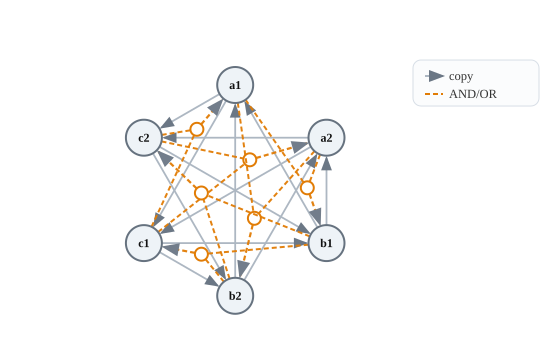

In [6]:
if plot_config["show_inline"]:
    display(SVG(topology_svg))


## 最优粗粒化图解读

最优分组保持了自然模块 `\{a1,a2\}`、`\{b1,b2\}`、`\{c1,c2\}`。在这个尺度上，宏观总 EI 达到 `3.000`，同时宏观总协同降到 `0.000`，宏观图只剩下 `B -> A`、`C -> B`、`A -> C` 三条 pairwise 边；也就是说，微观 readout 里那些局部门控依赖被吸收到宏观节点内部后，剩下的是一个干净的三节点环。


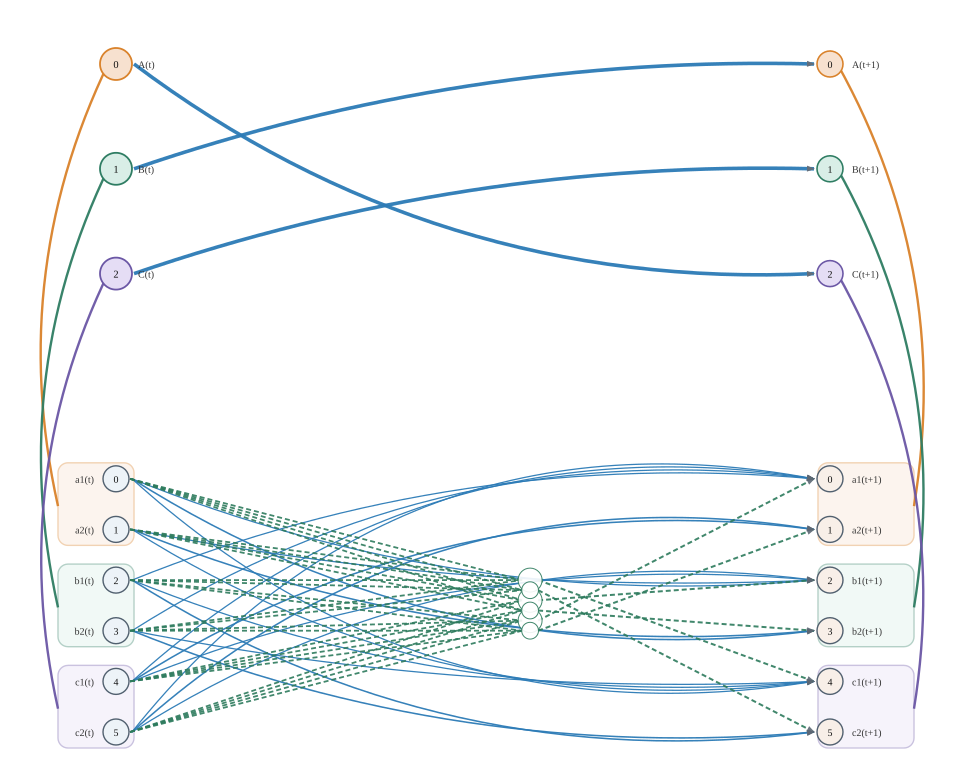

In [7]:
if plot_config["show_inline"]:
    display(SVG(optimal_comparison_svg))


## 代表性非最优粗粒化图解读

附录使用的非最优分组 `\{a1,a2\} | \{b1,c1\} | \{b2,c2\}` 把本来属于不同宏观块的 readout 混在了一起。于是宏观总 EI 掉到 `1.658`，宏观总协同升到 `0.393`，并且重新出现了约 `0.150` bit 的显著二源协同超边。这正好用来反衬最优粗粒化的意义：EI 没有被最大化时，宏观层暴露出来的往往不是更清楚的机制，而是错误分组制造出的伪高阶依赖。


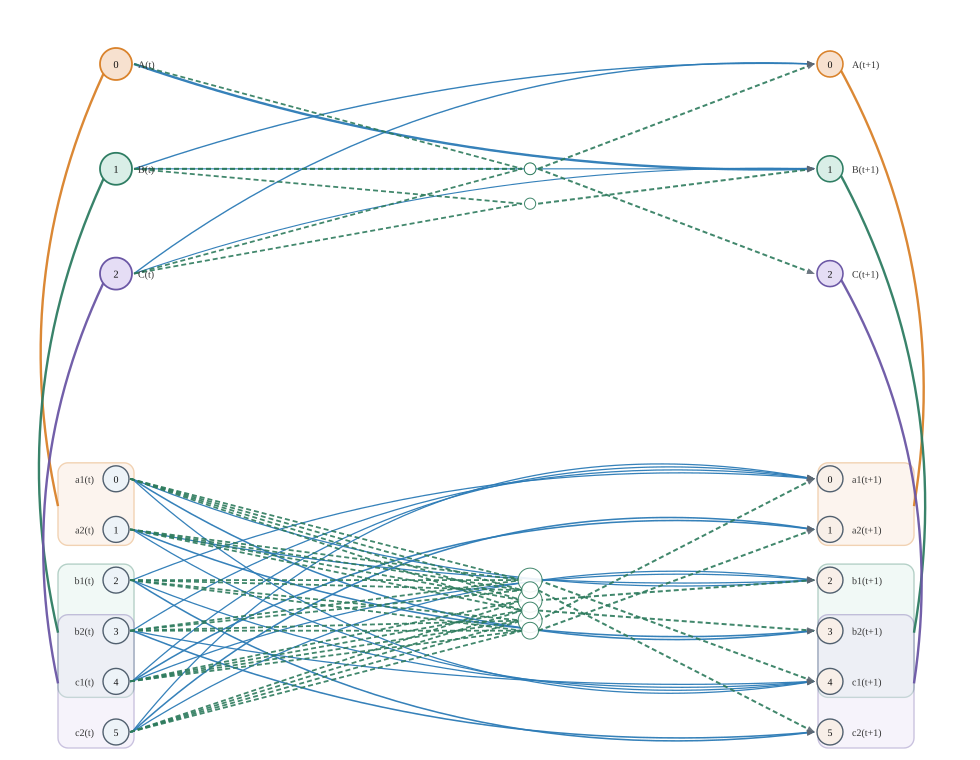

In [8]:
if plot_config["show_inline"]:
    display(SVG(nonoptimal_comparison_svg))


In [9]:
assert MANUAL_CASE_RESULTS["candidate_count"] == 90
assert MANUAL_CASE_RESULTS["optimal_groups"] == ((0, 1), (2, 3), (4, 5))
assert abs(MANUAL_CASE_RESULTS["optimal_ei"] - 3.0) < 1e-12
assert MANUAL_CASE_RESULTS["nonoptimal_groups"] == ((0, 1), (2, 4), (3, 5))
assert abs(MANUAL_CASE_RESULTS["nonoptimal_ei"] - 1.6582251715410803) < 1e-12
